In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_excel(r"../data/cleaned/master_dataset.xslx.xlsx")
df.head()

,city,date,aqi,pm2.5,pm10,no2,so2,co,o3,source,...,soil_texture,soil_organic_matter_%,disease_type,disease_severity,health_symptoms,age_group_affected,gender_most_affected,mitigation_measure,case_resolved,follow_up_required
0,Delhi,2018-01-01,406.0,223.3,438.48,336.98,462.84,4.26,385.7,Delhi AQI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Delhi,2018-01-02,418.0,229.9,451.44,346.94,476.52,4.39,397.1,Delhi AQI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Delhi,2018-01-03,382.0,210.1,412.56,317.06,435.48,4.01,362.9,Delhi AQI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Delhi,2018-01-04,366.0,201.3,395.28,303.78,417.24,3.84,347.7,Delhi AQI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Delhi,2018-01-05,390.0,214.5,421.20,323.70,444.60,4.10,370.5,Delhi AQI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(df.shape)
print(df.columns)
df.info()

(27804, 55)
Index(['city', 'date', 'aqi', 'pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3',
       'source', 'objectid', 'oceans', 'regions', 'subregions',
       'sampling_method', 'measurement', 'unit', 'density_range',
       'density_class', 'short_reference', 'long_reference', 'doi',
       'organization', 'keywords', 'accession_number', 'accession_link',
       'latitude', 'longitude', 'globalid', 'x', 'y', 'case_id',
       'date_reported', 'region', 'country', 'pollutant_type',
       'pollutant_concentration_mg_kg', 'soil_ph', 'temperature_c',
       'humidity_%', 'rainfall_mm', 'crop_type', 'farming_practice',
       'nearby_industry', 'water_source_type', 'soil_texture',
       'soil_organic_matter_%', 'disease_type', 'disease_severity',
       'health_symptoms', 'age_group_affected', 'gender_most_affected',
       'mitigation_measure', 'case_resolved', 'follow_up_required'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 27804 entries, 0 to 27803
Data columns (total 55 

In [10]:
pollution_cols = ["aqi", "pm2.5", "pm10"]

In [11]:
df["pollution_index"] = df[pollution_cols].mean(axis=1)

df[["pollution_index"]].head()

,pollution_index
0,355.926667
1,366.446667
2,334.886667
3,320.860000
4,341.900000


In [12]:
df["risk_score"] = df["pollution_index"]

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["risk_score_norm"] = scaler.fit_transform(df[["risk_score"]])

In [14]:
df[["risk_score", "risk_score_norm"]].head()

,risk_score,risk_score_norm
0,355.926667,0.812367
1,366.446667,0.837953
2,334.886667,0.761194
3,320.860000,0.727079
4,341.900000,0.778252


In [15]:
def risk_label(x):
    if x < 0.3:
        return "Low"
    elif x < 0.7:
        return "Medium"
    else:
        return "High"

df["risk_level"] = df["risk_score_norm"].apply(risk_label)

df[["risk_score_norm", "risk_level"]].head()

,risk_score_norm,risk_level
0,0.812367,High
1,0.837953,High
2,0.761194,High
3,0.727079,High
4,0.778252,High


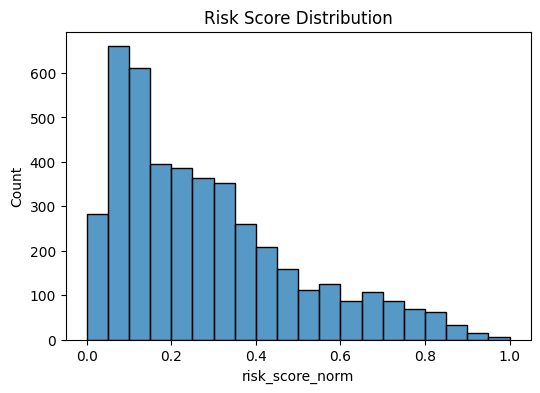

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["risk_score_norm"], bins=20)
plt.title("Risk Score Distribution")
plt.show()

In [17]:
df.to_csv("../data/features/feature_data.csv", index=False)

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["risk_score_norm"] = scaler.fit_transform(df[["risk_score"]])

df[["risk_score", "risk_score_norm"]].head()

,risk_score,risk_score_norm
0,355.926667,0.812367
1,366.446667,0.837953
2,334.886667,0.761194
3,320.860000,0.727079
4,341.900000,0.778252


In [24]:
df = df.dropna(subset=["risk_score_norm"])

In [25]:
def risk_label(x):
    if x < 0.3:
        return "Low"
    elif x < 0.7:
        return "Medium"
    else:
        return "High"

df["risk_level"] = df["risk_score_norm"].apply(risk_label)

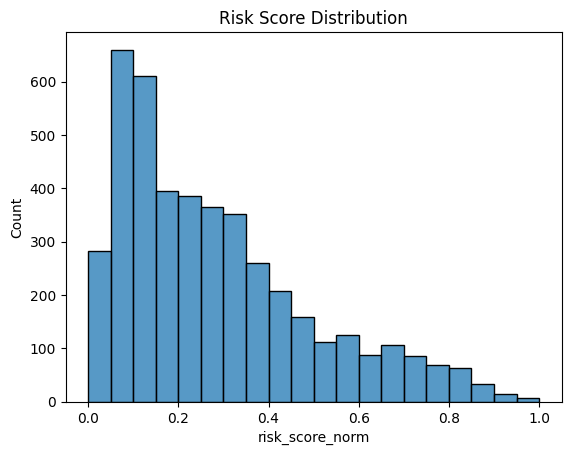

In [26]:
sns.histplot(df["risk_score_norm"], bins=20)
plt.title("Risk Score Distribution")
plt.show()

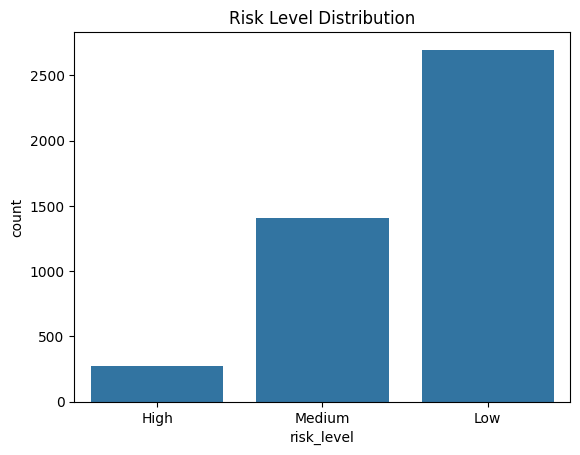

In [27]:
sns.countplot(x="risk_level", data=df)
plt.title("Risk Level Distribution")
plt.show()

In [28]:
df_model = df.select_dtypes(include=['number'])

In [29]:
df.to_csv("../data/features/feature_data.csv", index=False)
df_model.to_csv("../data/features/model_ready_data.csv", index=False)